# Model Training and Evaluation

This notebook focuses on training and comparing multiple Machine Learning algorithms for customer churn prediction.

Algorithms implemented:

1. Decision Tree Classifier
2. Random Forest Classifier
3. Support Vector Machine

Models are evaluated using:

- Cross Validation
- Hyperparameter Tuning
- Classification Metrics
- ROC-AUC Analysis

The objective is to identify the best model for deployment.

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import time


from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)


from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


import warnings
warnings.filterwarnings("ignore")

In [23]:
X_full = pd.read_csv(
    "../processed_data/full_features.csv"
)


X_selected = pd.read_csv(
    "../processed_data/selected_features.csv"
)


y = pd.read_csv(
    "../processed_data/target.csv"
)

In [24]:
y = y.values.ravel()

In [25]:
X_train_full, X_test_full, y_train, y_test = train_test_split(

    X_full,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [26]:
X_train_sel, X_test_sel, _, _ = train_test_split(

    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [27]:
models = {


"Decision Tree":

DecisionTreeClassifier(
random_state=42
),



"Random Forest":

RandomForestClassifier(
random_state=42
),



"SVM":

SVC(
probability=True,
random_state=42
)


}

In [28]:
results=[]


def train_evaluate(
    name,
    model,
    X_train,
    X_test,
    feature_type
):


    start=time.time()


    model.fit(
        X_train,
        y_train
    )


    end=time.time()


    pred=model.predict(
        X_test
    )


    prob=model.predict_proba(
        X_test
    )[:,1]



    results.append(
        
        [
            name,
            feature_type,
            
            accuracy_score(
                y_test,
                pred
            ),
            
            precision_score(
                y_test,
                pred
            ),
            
            recall_score(
                y_test,
                pred
            ),
            
            f1_score(
                y_test,
                pred
            ),
            
            roc_auc_score(
                y_test,
                prob
            ),
            
            end-start
        ]
    )

In [29]:
for name,model in models.items():

    train_evaluate(
        name,
        model,
        X_train_full,
        X_test_full,
        "Full"
    )

In [30]:
for name,model in models.items():

    train_evaluate(
        name,
        model,
        X_train_sel,
        X_test_sel,
        "Selected"
    )

In [31]:
comparison=pd.DataFrame(

results,

columns=[

"Algorithm",
"Feature Set",
"Accuracy",
"Precision",
"Recall",
"F1 Score",
"ROC-AUC",
"Training Time"

]

)


comparison

,Algorithm,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time
0,Decision Tree,Full,0.741661,0.513889,0.494652,0.504087,0.662297,0.041790
1,Random Forest,Full,0.786373,0.623729,0.491979,0.550075,0.825081,0.783067
2,SVM,Full,0.734564,0.000000,0.000000,0.000000,0.798654,6.407985
3,Decision Tree,Selected,0.717530,0.469697,0.497326,0.483117,0.647551,0.032536
4,Random Forest,Selected,0.792051,0.645161,0.481283,0.551302,0.814139,0.782488
5,SVM,Selected,0.734564,0.000000,0.000000,0.000000,0.798075,5.073193


Cross Validation divides data into multiple folds.

It provides a more reliable performance estimate compared to a single train-test split because every data point gets a chance for training and validation.

In [32]:
for name,model in models.items():

    scores=cross_val_score(

        model,
        X_full,
        y,
        cv=5,
        scoring="accuracy"

    )


    print(name)


    print(
        "Mean:",
        scores.mean()
    )


    print(
        "STD:",
        scores.std()
    )

    print()

Decision Tree
Mean: 0.7306555060003871
STD: 0.007724133508693025

Random Forest
Mean: 0.7905737870185174
STD: 0.010311955821938933

SVM
Mean: 0.7346301575908123
STD: 0.0002389625185129842



In [33]:
params={

"n_estimators":[100,200,300],

"max_depth":[5,10,20,None],

"min_samples_split":[2,5,10],

"min_samples_leaf":[1,2,4]


}

In [34]:
grid=GridSearchCV(

RandomForestClassifier(
random_state=42
),

params,

cv=5,

scoring="f1",

n_jobs=-1

)


grid.fit(
X_train_full,
y_train
)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [35]:
grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

In [36]:
best_model=grid.best_estimator_


prediction=best_model.predict(
    X_test_full
)

In [37]:
print(

classification_report(
    y_test,
    prediction
)

)

              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1035
        True       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



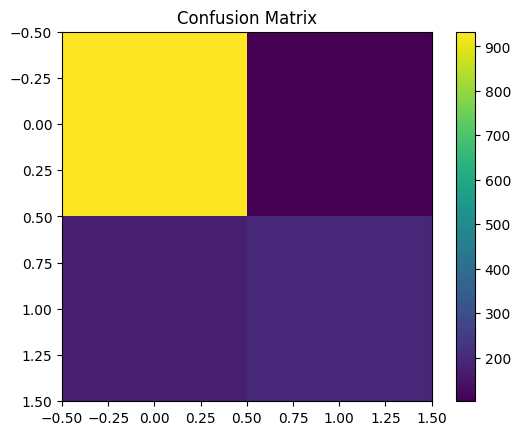

In [38]:
cm=confusion_matrix(
    y_test,
    prediction
)


plt.imshow(
    cm
)


plt.colorbar()


plt.title(
    "Confusion Matrix"
)


plt.show()

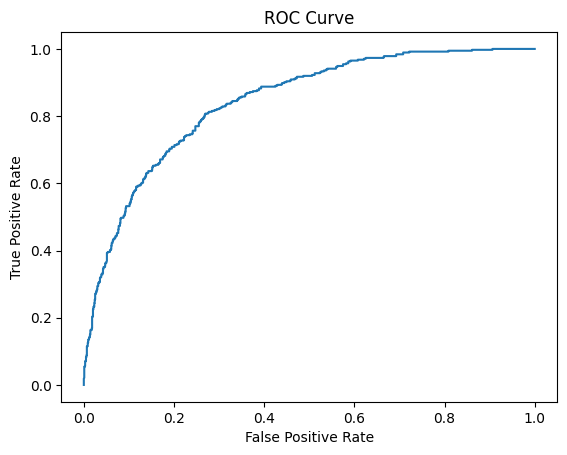

In [39]:
prob=best_model.predict_proba(
    X_test_full
)[:,1]


fpr,tpr,_=roc_curve(
    y_test,
    prob
)


plt.plot(
    fpr,
    tpr
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve"
)


plt.show()

In [40]:
import joblib


joblib.dump(
    best_model,
    "../models/churn_prediction_model.pkl"
)

['../models/churn_prediction_model.pkl']

## Final Model Selection

Random Forest Classifier was selected as the final deployment model.

Reasons:

- Highest ROC-AUC performance
- Handles categorical relationships effectively
- Reduces overfitting using multiple trees
- Provides feature importance interpretation

Important churn indicators:

1. Contract type
2. Customer tenure
3. Monthly charges
4. Payment method
5. Online services

These features help identify customers with higher cancellation risk.

In [41]:
joblib.dump(
    list(X_train_full.columns),
    "../models/model_features.pkl"
)


print(
    "Feature names saved")

Feature names saved


In [42]:
joblib.dump(
    list(X_selected.columns),
    "../models/selected_features.pkl"
)


print(
    "Selected features saved"
)

Selected features saved
